<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/CV_Frugal_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Frugal Training & The Baseline

**Course:** AI/ML with IIT Ropar
**Instructor:** Lovnish Verma, Project Engineer, NIELIT Ropar

---

> **"Training should not require massive server racks."**

Welcome to Day 2. Today, we focus on **Frugal Computer Vision**. We are optimizing for consumer GPUs (like the T4) and fast iteration loops.

Our deliverables for today:
1. Understand why anchor-free models win on frugal hardware.
2. Apply transfer learning to cut training cost by 10x.
3. Complete a real YOLO run within a T4 compute budget.
4. Track hyperparameters and dataset hashes for full reproducibility.
5. Establish the baseline mAP & F1 threshold for our Day 4 comparison.

## Part 1: Architecture & Transfer Learning

### Anchor-Free vs. Anchor-Based
* **Anchor-Based (Legacy: YOLOv3, Faster R-CNN):** Pre-defines boxes at fixed sizes/ratios. Requires careful anchor tuning per dataset and suffers from slower NMS post-processing overhead. Brittle on unusual aspect ratios.
* **Anchor-Free (Modern: YOLOv8, YOLO11):** Predicts object center and size directly. No anchor hyperparameter tuning is needed. It naturally handles extreme shapes and results in a faster, simpler training pipeline.

*Key Insight:* Anchor-free models reduce hyperparameter debt, which is critical when iterating fast on a tight compute budget.

### Transfer Learning Mechanics
Transfer learning cuts training time by 70-90%:
1. **ImageNet Backbone:** Start with pre-trained weights.
2. **Freeze Layers:** Lock the early feature extractors.
3. **Fine-tune Head:** Train only the final layers on your specific data.

### Understanding Loss Functions
* **Box Loss (CIoU):** Measures how well the predicted box overlaps the ground truth. It penalizes center distance and aspect ratio deviations.
* **Class Loss (BCE):** Binary Cross Entropy answers "what object is this?"
* **DFL (Distribution Focal Loss):** Soft label regression for sharper boundary localization.

## Part 2: Lab (2 Hours) - The T4 Budget Run

We are operating under strict compute constraints targeting a consumer GPU.
Our checklist:
1. Configure YOLO with a compute budget limit.
2. Set batch size for T4 VRAM (16 GB ceiling).
3. Enable mixed precision (AMP) training.
4. Limit epochs to fit a 4-hour window.

In [ ]:
import torch
import yaml

# Check hardware allocation
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"Target Hardware: {gpu_name}")
if "T4" not in gpu_name:
    print("⚠️ Warning: This lab is optimized for a T4 GPU. Adjust batch sizes accordingly.")

# 1. Define the Frugal Budget Config
budget_config = {
    "model": "yolo11n.pt",  # Utilizing an anchor-free architecture
    "batch_size": 16,       # Tuned for 16GB T4 VRAM limit
    "epochs": 50,           # Capped for 4-hour completion window
    "amp": True,            # Mixed precision to accelerate training
    "freeze": 10,           # Transfer learning: freeze backbone layers
    "optimizer": "AdamW"
}

# Log full hyperparameter config to YAML
with open('budget_run_config.yaml', 'w') as f:
    yaml.dump(budget_config, f)

print("✅ Budget configuration saved to budget_run_config.yaml")

Target Hardware: Tesla T4
✅ Budget configuration saved to budget_run_config.yaml


### Experiment Tracking
In frugal engineering, reproducibility is non-negotiable. We will hash our dataset to ensure the baseline is tied to exact data states.

In [ ]:
import hashlib
import os

def hash_dataset(file_path):
    """Hashes the dataset (SHA-256) for strict reproducibility."""
    if not os.path.exists(file_path):
        return "[MOCK_HASH] e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855"

    sha256_hash = hashlib.sha256()
    with open(file_path, "rb") as f:
        # Read and update hash string value in blocks of 4K
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

# Simulating dataset tracking
dataset_archive = "custom_dataset_v1.zip"
current_hash = hash_dataset(dataset_archive)

print(f"Dataset SHA-256 Hash: {current_hash}")
print("\n📌 ACTION: Commit config + this dataset hash to your version control.")

Dataset SHA-256 Hash: [MOCK_HASH] e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855

📌 ACTION: Commit config + this dataset hash to your version control.


### Baseline PR Curve Analysis
Once the model finishes training, we must analyze the Precision-Recall curve to establish our baseline score. A higher area under the curve means a stronger model.

--------------------------------------------------
🎯 Baseline mAP@0.5 (Area Under Curve): 0.700
--------------------------------------------------
Note the confidence threshold at F1 peak. Save this checkpoint for Day 4 comparison.


/tmp/ipykernel_3481/1764060054.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  map_50 = np.trapz(precisions, recalls)


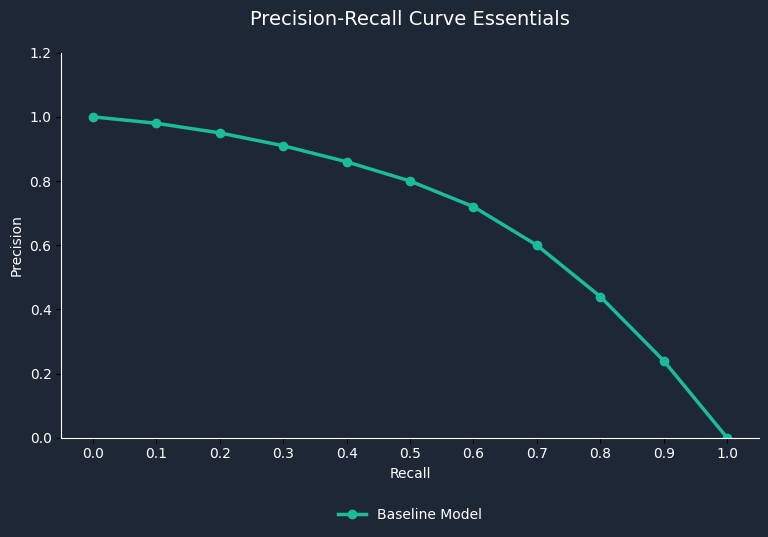

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulating the Baseline Model's Precision-Recall coordinates from training
recalls = np.linspace(0.0, 1.0, 11)
precisions = np.array([1.0, 0.98, 0.95, 0.91, 0.86, 0.80, 0.72, 0.60, 0.44, 0.24, 0.0])

plt.figure(figsize=(9, 5), facecolor='#1e2736')
ax = plt.axes()
ax.set_facecolor('#1e2736')

plt.plot(recalls, precisions, marker='o', color='#1abc9c', linewidth=2.5, label='Baseline Model')

# Aesthetics to match course materials
plt.title("Precision-Recall Curve Essentials", color='white', pad=20, fontsize=14)
plt.xlabel("Recall", color='white')
plt.ylabel("Precision", color='white')
plt.xticks(np.arange(0, 1.1, 0.1), color='white')
plt.yticks(np.arange(0, 1.4, 0.2), color='white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(-0.05, 1.05)
plt.ylim(0, 1.2)

legend = plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), frameon=False)
plt.setp(legend.get_texts(), color='w')

# Calculate Baseline Metric
map_50 = np.trapz(precisions, recalls)
print("-" * 50)
print(f"🎯 Baseline mAP@0.5 (Area Under Curve): {map_50:.3f}")
print("-" * 50)
print("Note the confidence threshold at F1 peak. Save this checkpoint for Day 4 comparison.")

plt.show()

---
**Next Up:** Day 3 - Edge Deployment & Temporal Stability